/Users/inside/miniforge3/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/inside/miniforge3/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


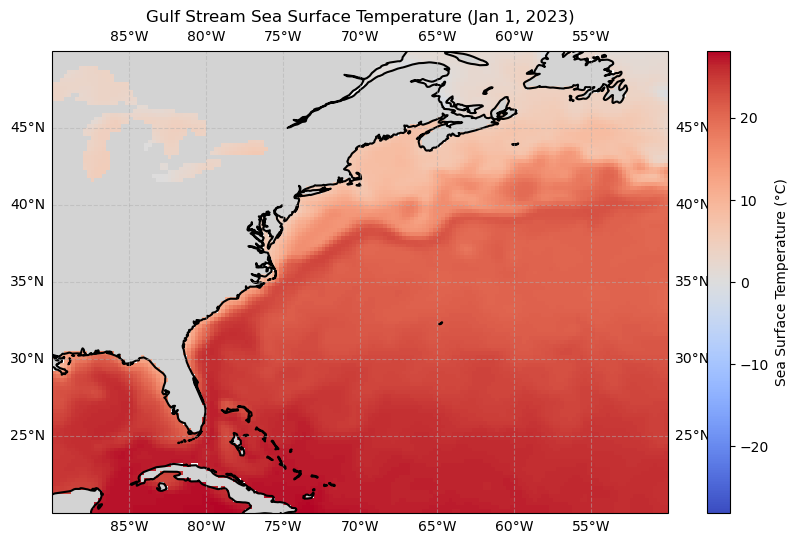

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Connecting to NOAA's server via OPeNDAP
url = "https://psl.noaa.gov/thredds/dodsC/Datasets/noaa.oisst.v2.highres/sst.day.mean.2023.nc"
ds = xr.open_dataset(url)

# Slicing the data and setting lat lon for US East Coast
sst_map = ds.sst.sel(time='2023-01-01').sel(lat=slice(20, 50), lon=slice(270, 310))

# 3.Maping projection
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# 4. Adding geographic features
ax.add_feature(cfeature.COASTLINE, linewidth=1.5)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

# 5. Ploting the ocean temperature data
sst_map.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='coolwarm',
             cbar_kwargs={'label': 'Sea Surface Temperature (°C)'})

plt.title('Gulf Stream Sea Surface Temperature (Jan 1, 2023)')
plt.savefig("../figures/gulf_stream_sst.png", dpi=300, bbox_inches='tight')
plt.show()